In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode

In [2]:
# parameters
region_level = "nuts4"
year = 2017

**PF1 -- co-location illustration**

**PF2 -- coagglomeration illustration**

In [17]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [10]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [ ]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

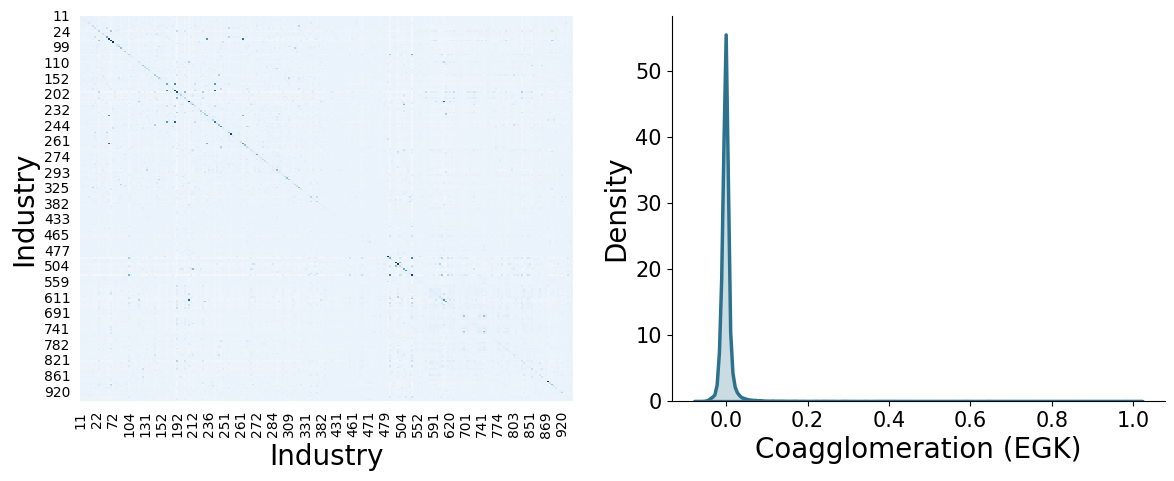

In [24]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
textsize = 20
key_var = "egk_coagg"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Blues",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (EGK)",
    fontsize=textsize
)

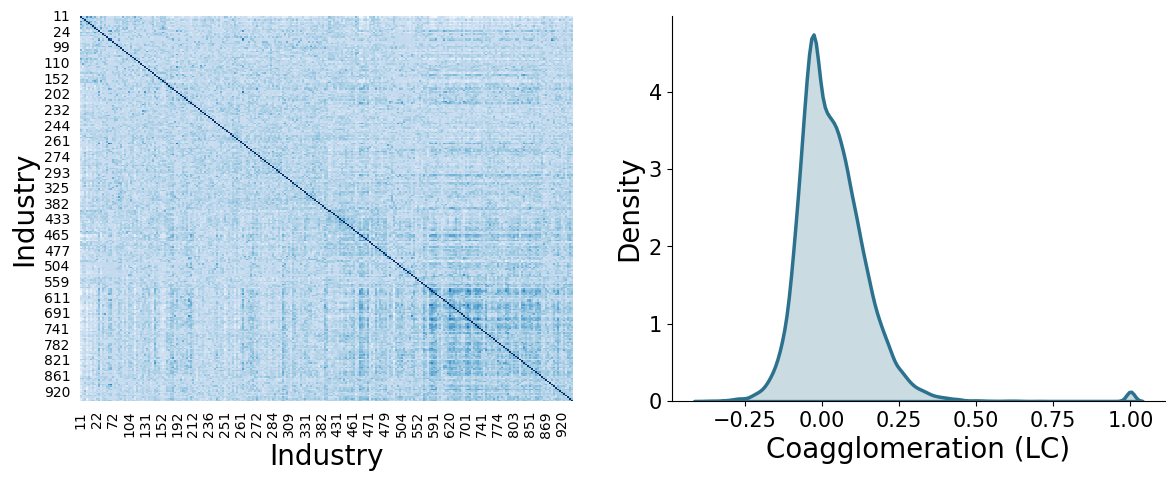

In [26]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
textsize = 20
key_var = "coagg_porter_rca01"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Blues",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (LC)",
    fontsize=textsize
)

**PF3 -- IO data illustration**

In [27]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

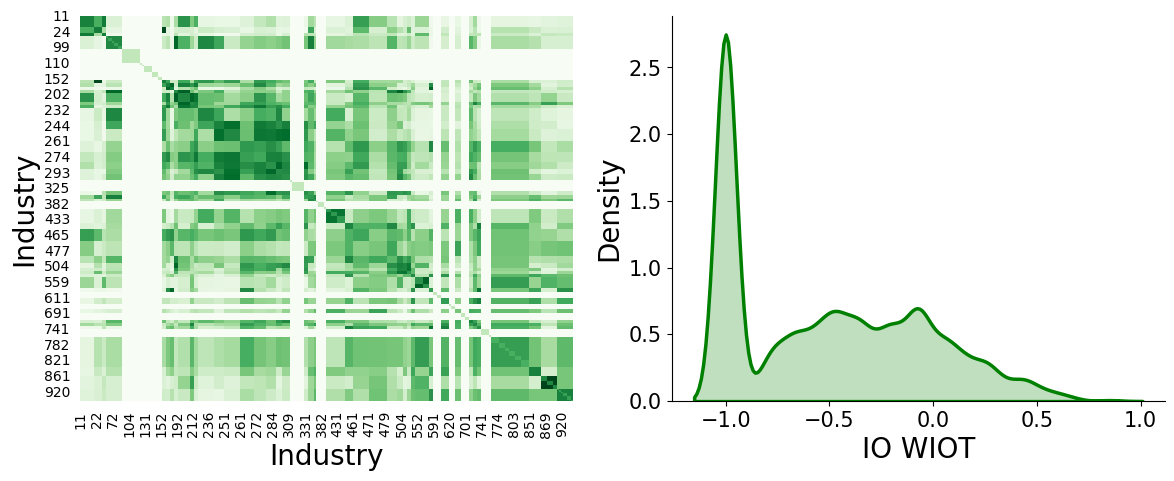

In [33]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
textsize = 20
key_var = "io_wiot_hun"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Greens",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Green",
    xlabel_text="IO WIOT",
    fontsize=textsize
)

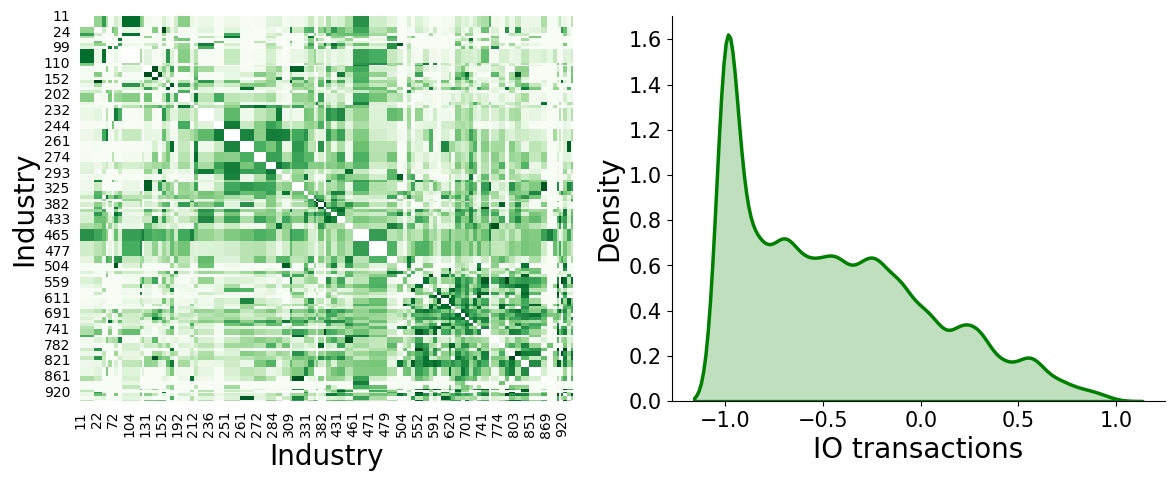

In [34]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
textsize = 20
key_var = "io_norm2"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Greens",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Green",
    xlabel_text="IO transactions",
    fontsize=textsize
)

**PF4 -- labor data illustration**

In [36]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

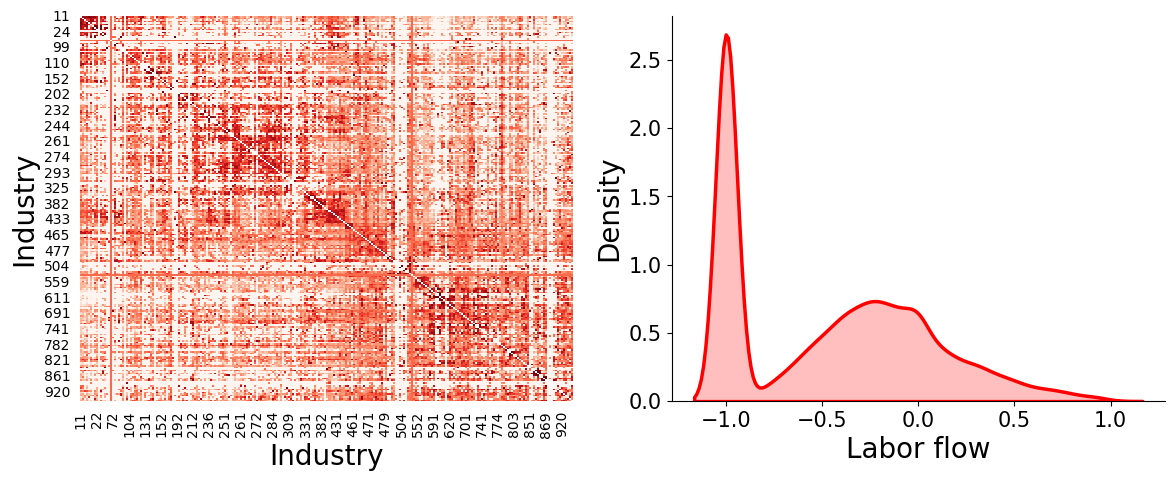

In [39]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
textsize = 20
key_var = "sr_norm"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Reds",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Red",
    xlabel_text="Labor flow",
    fontsize=textsize
)

### Co-location examples

In [32]:
reg_df.columns

Index(['ind1_2d', 'ind2_2d', 'ind1', 'ind2', 'egk_coagg', 'egk_coagg_mne',
       'egk_coagg_local', 'coagg_porter_emp', 'coagg_porter_emp_mne',
       'coagg_porter_emp_local', 'coagg_porter_emp_mixed',
       'coagg_porter_rca01', 'coagg_porter_rca01_mne',
       'coagg_porter_rca01_local', 'coagg_porter_rca01_mixed', 'coagg_mat',
       'coagg_mat_mne', 'coagg_mat_local', 'coagg_mat_mixed', 'sr_norm',
       'swe_sr_norm', 'io_norm2', 'io_norm3', 'io_wiot_hun', 'swe_io_norm',
       'iv_us_supply_norm', 'iv_wiot_mean', 'iv_wiot_usa', 'iv_wiot_swe',
       'iv_wiot_cze'],
      dtype='object')

In [29]:
# co-location examples 
loc_df = pd.read_csv("../data/firmdata_with_latlon.csv", converters={'coords': eval})[["oo_cegj_sz", "hely", "coords"]]
firm_info = pd.read_csv("../outputs/opten_firm_nace.csv", sep=";")

loc_df = pd.merge(
    loc_df,
    firm_info,
    on="oo_cegj_sz",
    how="left"
)

# clean up coords
loc_df = loc_df[loc_df["coords"] != 0]
loc_df[["lon", "lat"]] = pd.DataFrame(loc_df.coords.tolist(), index=loc_df.index)
loc_df["geometry"] = loc_df.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
loc_df = loc_df.set_geometry("geometry")

# create 3 digit NACE codes for plot
loc_df["nace3d"] = loc_df["fotev_kod"] // 100

<AxesSubplot: >

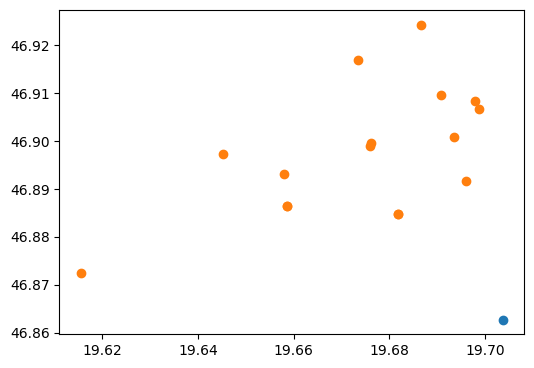

In [30]:
# MBMH Kecskemet 01 09 902102 
fig, ax = plt.subplots(1,1, figsize=(6,5))

loc_df[loc_df["oo_cegj_sz"]=="01 09 902102"].plot(ax=ax)
loc_df[(loc_df["nace3d"]==522) & (loc_df["hely"] == "Kecskemét")].plot(ax=ax)

/opt/homebrew/lib/python3.10/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 29 is not valid for the current tile provider (valid zooms: 0 - 18).
  warnings.warn(msg)


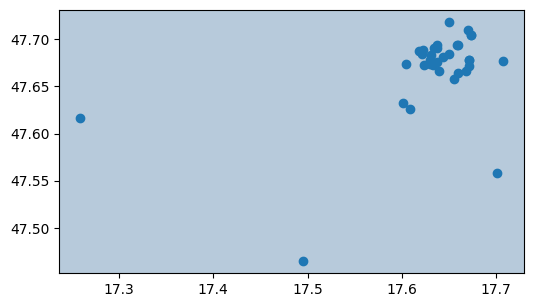

In [40]:
# AUDI Gyor 08 10 001840
fig, ax = plt.subplots(1,1, figsize=(6,5))

#loc_df[loc_df["oo_cegj_sz"]=="08 10 001840"].plot(ax=ax)
fs = loc_df[(loc_df["nace3d"]==522) & (loc_df["hely"] == "Gyõr")].plot(ax=ax)
ctx.add_basemap(fs, url=ctx.providers.Stamen.TonerLite, alpha=0.7, attribution=False)

In [39]:
# contextily OR osm
# add osmnx network of roads..
import contextily as ctx

# pl is 
# ctx.add_basemap(pl, url=ctx.providers.Stamen.TonerLite, alpha=0.7, attribution=False)

### Coagglomeration - IO connections - Labor flow visuals

In [3]:
# coagg / IO / SR matrix visuals
el1 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_oc.csv", sep=";")

def norm01(values):
    new_values = (values - min(values)) / (max(values) - min(values))
    return new_values

def z_score(values):
    new_values = (values - np.mean(values)) / (max(values) - min(values))
    return new_values

In [4]:
# variables manipulation
el1["egk_coagg_norm"] = norm01(el1["egk_coagg"])
el1["egk_coagg_z"] = z_score(el1["egk_coagg"])

el1["log_undir_value"] = np.log10(el1["undir_value"])
el1.replace([np.inf, -np.inf], 0, inplace=True)

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
def mpp_matrix(df, key_cols, sort_matrix, heatmap, fontsize, cmap, ax=None):
    """matrix visualization"""
    table = df[key_cols]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_cols]
    table = pd.concat([table, table2])

    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
     
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

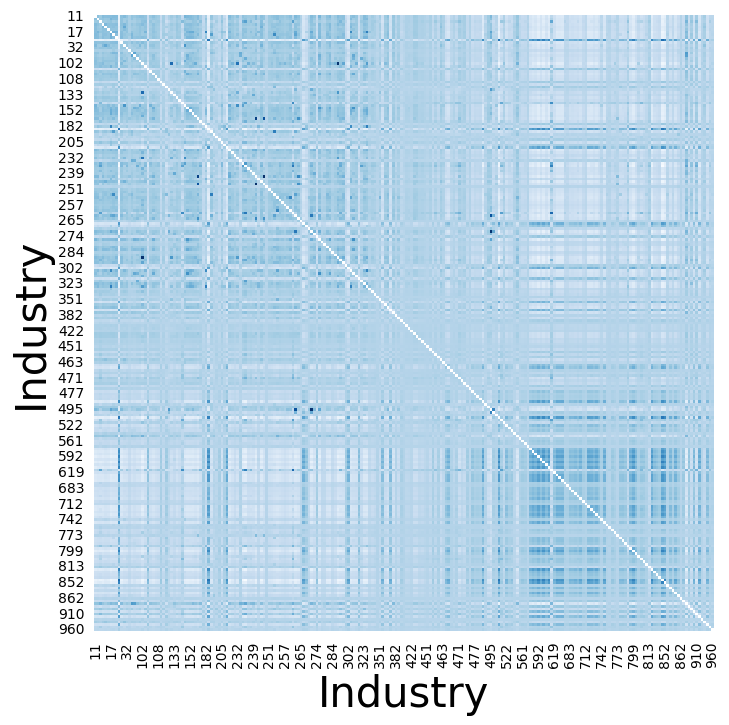

In [8]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "egk_coagg_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Blues", ax=None)

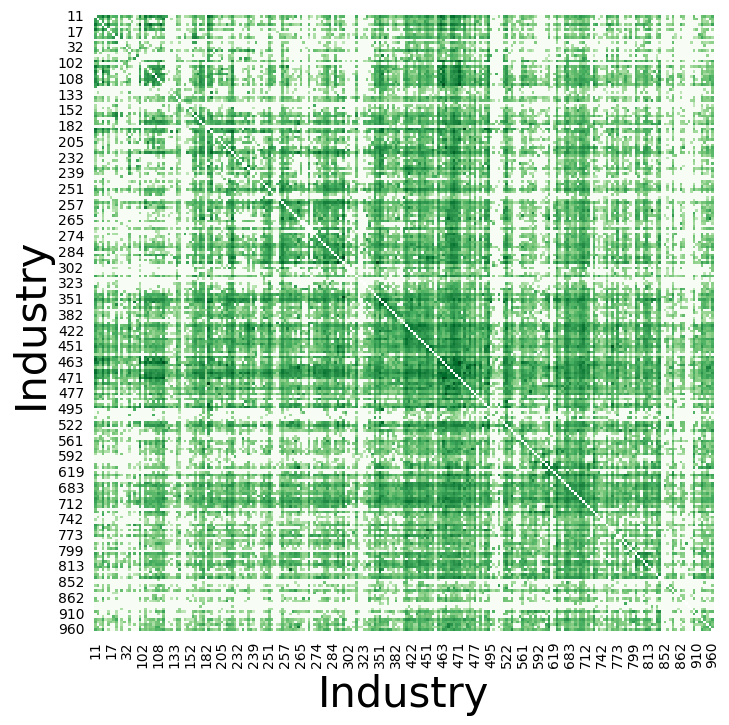

In [9]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "log_undir_value"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Greens", ax=None)

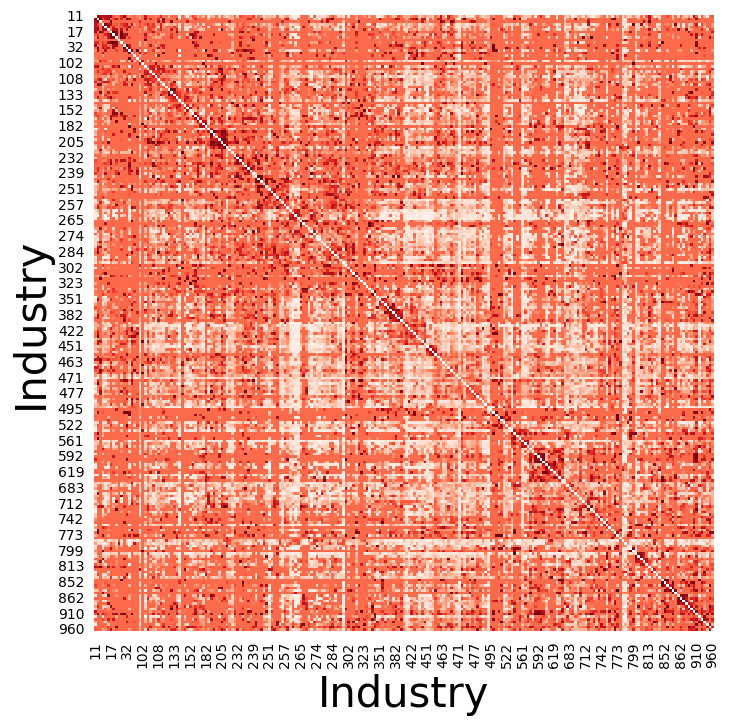

In [10]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "hun_sr_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Reds", ax=None)


### Constructing coagglomeration measures from Mcp


In [10]:
# industry-region data with RCAs
indreg = pd.read_csv("../data/oc_2022_november/indreg_2018_2020_megye.csv", sep=";")
indreg["rca01"] = (indreg["rca18"] >= 1).astype(int)

In [23]:
def mcp_matrix_plot(df, key_cols, transpose, heatmap, labels, size, ax=None):
    """ Mcp matrix visualization """
    table = df[key_cols]
    
    table = pd.pivot_table(table,
        values=key_cols[2],
        index=[key_cols[1]],
        columns=[key_cols[0]],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
    
    if transpose==True:
        table = table.transpose()

    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        #ax.set_title("RCA 0/1", size=size)
        ax.set_xlabel(labels[0], size=size)
        ax.set_ylabel(labels[1], size=size)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

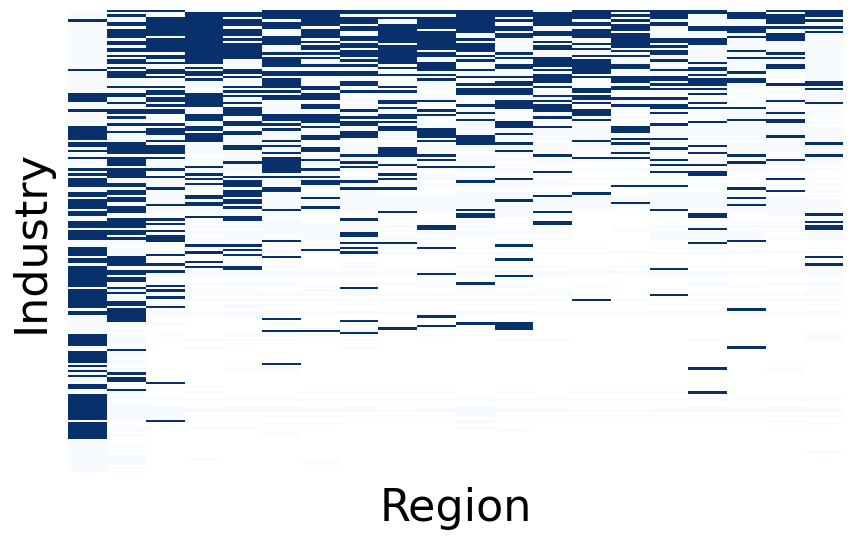

In [29]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
mcp_matrix_plot(indreg, key_cols=["reg", "ind", "rca01"], transpose=False, labels=["Region", "Industry"], size=32, heatmap=True, ax=ax)

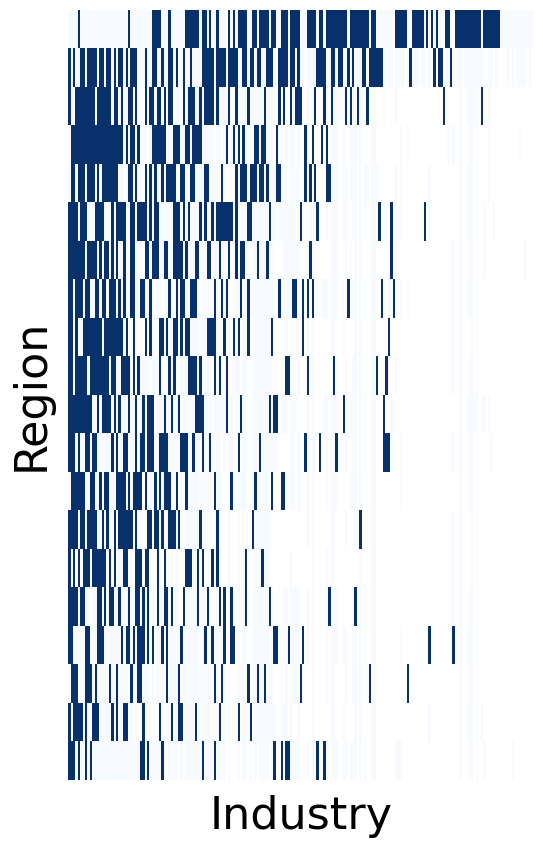

In [30]:
fig, ax = plt.subplots(1,1, figsize=(6,10))
mcp_matrix_plot(indreg, key_cols=["reg", "ind", "rca01"], transpose=True, labels=["Industry", "Region"], size=32, heatmap=True)

### correlation of resulted coagglomeration measures

In [3]:
# regression dataframe
mdf3 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_OC.csv", sep=";")

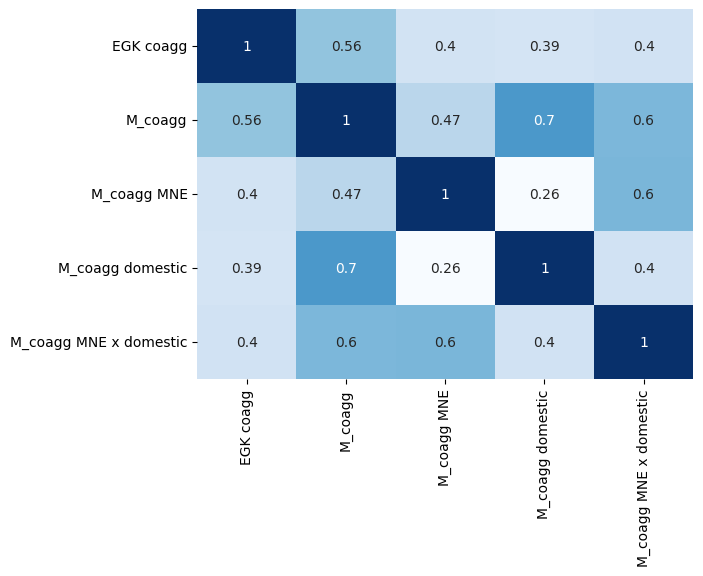

In [13]:
def correlation_matrix(data, key_cols, heatmap, labels, ax=None):
    corr_df = data[key_cols].corr()

    if heatmap==False:
        return corr_df
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(corr_df, cbar=False, annot=True, cmap="Blues", ax=ax)
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

labels = ["EGK coagg", "M_coagg", "M_coagg MNE", "M_coagg domestic", "M_coagg MNE x domestic"]
correlation_matrix(mdf3, key_cols=["egk_coagg", "coagg", "coagg_mne", "coagg_local", "coagg_mne_local"], heatmap=True, labels=labels)

### MNE visuals

In [18]:
# parameters
region_level = "megye"
# region_level = "jaras"

In [19]:
# 1 -- distribution of MNEs
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_" + str(region_level) +".csv", sep=";")
region_gdf = gpd.read_file("../data/shape_files/" + str(region_level) + "_shape.geojson")
key_table = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")

In [21]:
# join region codes to shape
key_table = key_table.filter(regex=region_level).drop_duplicates()
key_column = str(region_level) + "_nev"
plot_df = pd.merge(
    region_gdf,
    key_table,
    left_on="region_name",
    right_on=key_column,
    how="left"
)

In [23]:
# aggregate MNE data
group_col = str(region_level) + "_kod"

region_mne_agg_table = mne_df.groupby(group_col)\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

region_mne_agg_table["mne_firm_share"] = region_mne_agg_table["nr_mnes"] / region_mne_agg_table["nr_firms"]
region_mne_agg_table["mne_emp_share"] = region_mne_agg_table["mne_emp"] / region_mne_agg_table["total_emp"]

In [41]:
# aggregate MNE data to manufacturing only?
manuf_mne_df = mne_df[(mne_df["nace3d"]>=100) & (mne_df["nace3d"]<350)]

# need to go back to check the limits for services
serv_mne_df = mne_df[mne_df["nace3d"]<960]

,megye_kod,nace3d,mne_count,nr_firms,total_emp,emp_max_hozz,mne_emp,mne_emp_share,mne_dom_25,mne_dom_50,mne_dom_75
10,1,101,3,66,2738,0.117969,114,0.041636,0,0,0
11,1,103,4,33,769,0.318596,426,0.553966,1,1,0
12,1,105,2,17,1033,0.446273,499,0.483059,1,0,0
13,1,106,0,9,253,0.517787,0,0.000000,0,0,0
14,1,107,40,270,3884,0.090371,1257,0.323635,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2386,20,310,1,43,1353,0.404287,144,0.106430,0,0,0
2387,20,323,0,5,27,0.407407,0,0.000000,0,0,0
2388,20,325,0,10,43,0.232558,0,0.000000,0,0,0
2389,20,331,0,22,114,0.228070,0,0.000000,0,0,0


In [25]:
# merge MNE data to map
key_col = str(region_level) + "_kod"
plot_df = pd.merge(
    plot_df,
    region_mne_agg_table,
    on=key_col,
    how="left"
)

In [27]:
def plot_mnes_on_map(df, key_var, colormap, label_text, fontsize, ax=None):
    """function to create map of MNE firms in Hungary"""
    if ax is None:
        ax = plt.gca()

    # map part    
    df.plot(column=key_var, cmap=colormap, edgecolor="white", linewidth=0.15, ax=ax)
    
    # colorbar
    vmin = df[key_var].min()
    vmax = df[key_var].max()
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, fraction=0.04, pad=0.0001, shrink=0.7, ax=ax)
    cbar.ax.set_ylabel(label_text, rotation=90, size=fontsize)
    cbar.ax.get_yaxis().labelpad = 5

    ax.axis('off')

# plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=14)

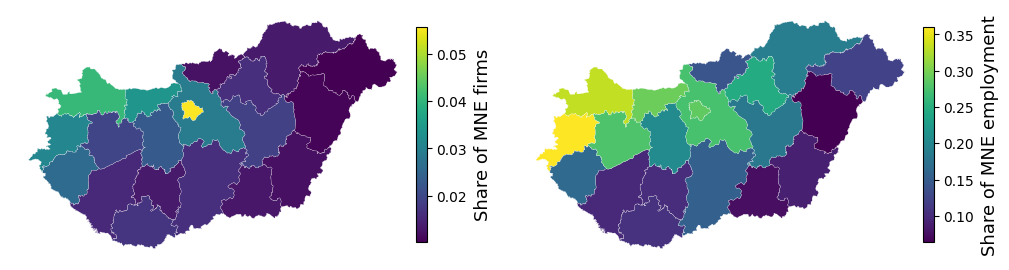

In [28]:
# grid of different plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_mnes_on_map(plot_df, key_var="mne_firm_share", colormap="viridis", label_text="Share of MNE firms", fontsize=13, ax=ax[0])
plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=13, ax=ax[1])

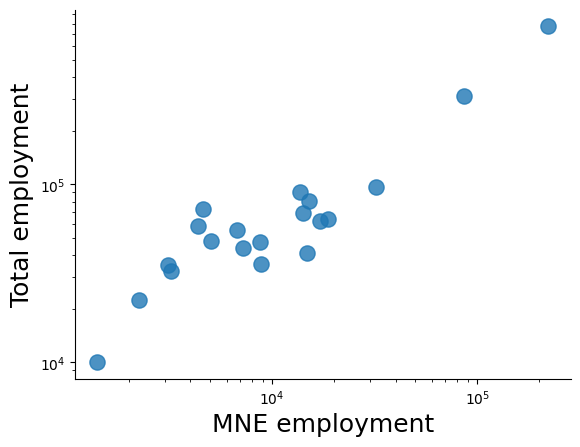

In [36]:
def scatter_mne_total(df, key_var, labels, fontsize, ax=None):
    """function to illustrate the relationship between total EMP and MNE emp in regions"""
    if ax is None:
        ax = plt.gca()
    
    ax.scatter(df[key_var[0]], df[key_var[1]], s=120, alpha=0.8)
    ax.loglog()
    ax.set_xlabel(labels[0], size=fontsize)
    ax.set_ylabel(labels[1], size=fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

scatter_mne_total(plot_df, key_var=["mne_emp", "total_emp"], labels=["MNE employment", "Total employment"], fontsize=18)

In [ ]:

scatter_mne_total(plot_df, key_var=["mne_emp", "total_emp"], labels=["MNE employment", "Total employment"], fontsize=18)

In [5]:
# MNEs per industry figure
mne_df["nace2d"] = mne_df["nace3d"] // 10
mne_ind_table = mne_df.groupby(["nace2d"])\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        nr_mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

mne_ind_table["share_mne_firms"] = mne_ind_table["nr_mnes"] / mne_ind_table["nr_firms"]
mne_ind_table["share_mne_emp"] = mne_ind_table["nr_mne_emp"] / mne_ind_table["total_emp"]

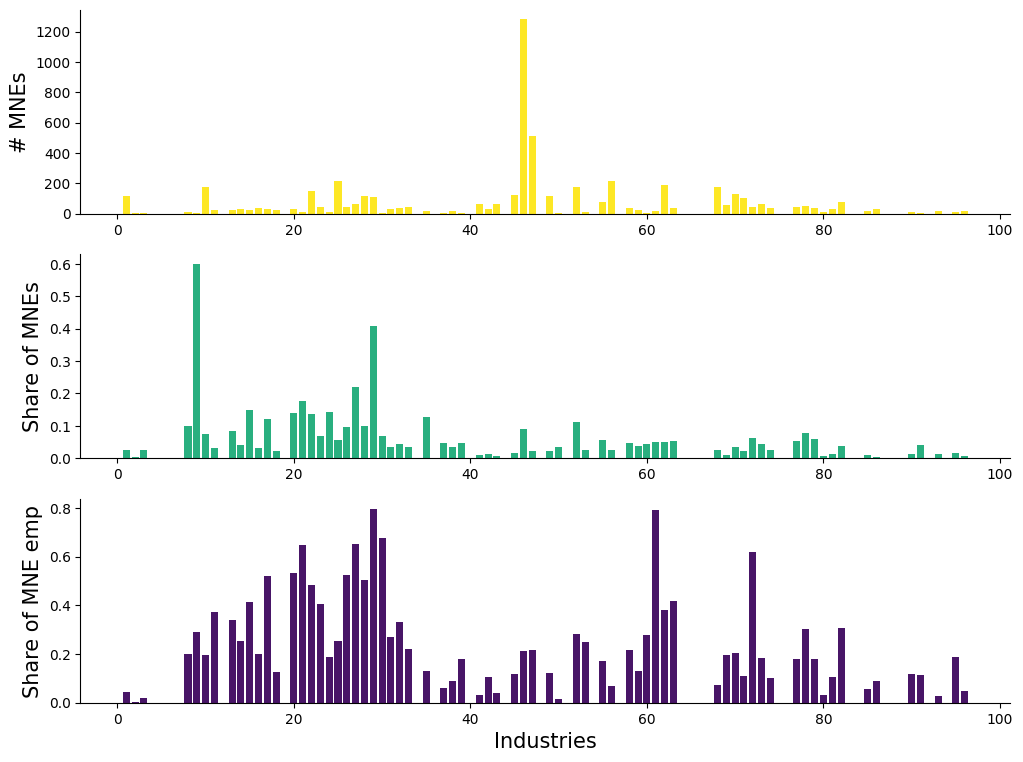

In [16]:
def plot_mne_per_industry(df, ind_col, key_col, color_code, ylabel_text, fontsize, xlabel_text=None, ax=None):
    """function to illustrate the distribution of MNEs across industries in Hungary"""
    if ax is None:
        ax = plt.gca()

    # plot
    ax.bar(df[ind_col], df[key_col], color=color_code)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel_text, size=fontsize)
    if xlabel_text is None:
        ax.set_xlabel("", size=fontsize)
    else:
        ax.set_xlabel(xlabel_text, size=fontsize)

fig = plt.figure(figsize=(12,9))
ax = [0]*3

gs = GridSpec(3,1, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[1,0])
ax[2] = fig.add_subplot(gs[2,0])
plot_mne_per_industry(mne_ind_table, "nace2d", "nr_mnes", color_code="#FDE725FF", ylabel_text="# MNEs", fontsize=15, ax=ax[0])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_firms", color_code="#29AF7FFF", ylabel_text="Share of MNEs", fontsize=15, ax=ax[1])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_emp", color_code="#481567FF", ylabel_text="Share of MNE emp", fontsize=15, xlabel_text="Industries", ax=ax[2])


In [4]:
# networks inside regions -- statistics from m09_.ipynb
rnet_table = pd.read_csv("../outputs/region_network_descriptive.csv", sep=";")

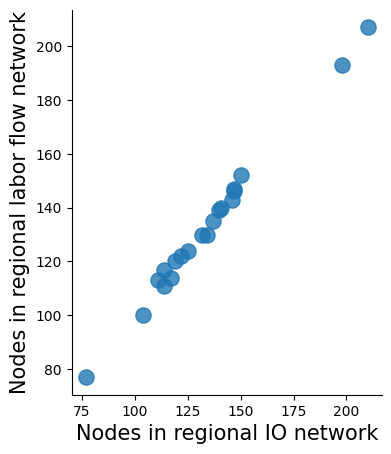

In [151]:
fig, ax = plt.subplots(1,1, figsize=(4,5))
ax.scatter(rnet_table["io_nodes"], rnet_table["lab_nodes"], s=120, alpha=0.8)
ax.set_xlabel("Nodes in regional IO network", size=15)
ax.set_ylabel("Nodes in regional labor flow network", size=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

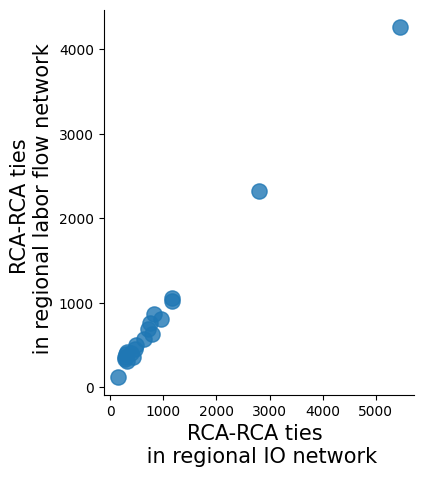

In [153]:
fig, ax = plt.subplots(1,1, figsize=(4,5))
ax.scatter(rnet_table["io_edges_rca"], rnet_table["lab_edges_rca"], s=120, alpha=0.8)
ax.set_xlabel("RCA-RCA ties \n in regional IO network", size=15)
ax.set_ylabel("RCA-RCA ties \n in regional labor flow network", size=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.loglog()

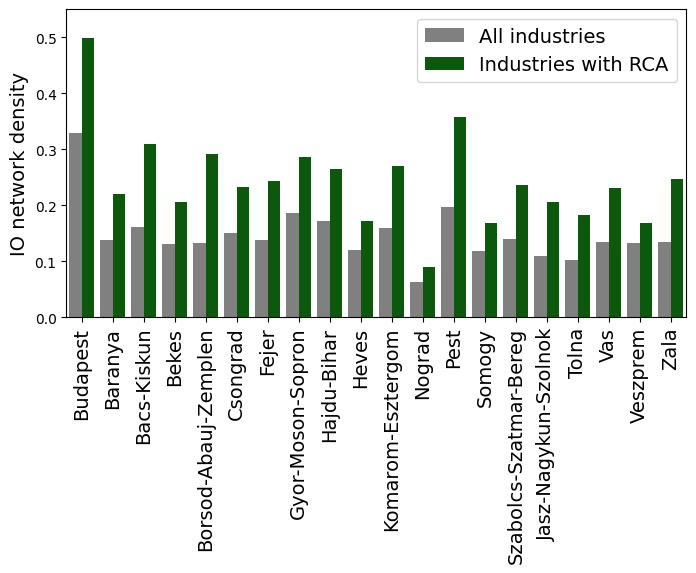

In [161]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "io_density", "io_density_rca"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "density_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Grey", "Darkgreen"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="density_type", palette = colors, ax=ax)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("IO network density", size=14)

legend_labels = ["All industries", "Industries with RCA"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=14)
plt.show()

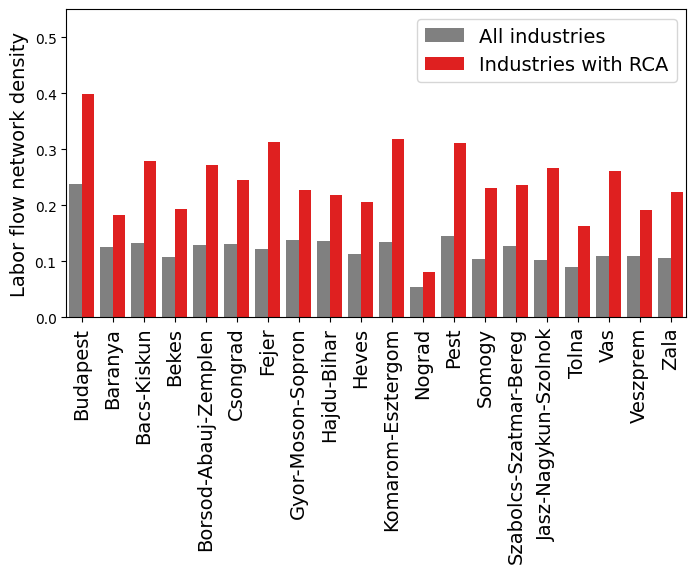

In [162]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "lab_density", "lab_density_rca"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "density_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Grey", "Red"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="density_type", palette = colors, ax=ax)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("Labor flow network density", size=14)

legend_labels = ["All industries", "Industries with RCA"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=14)
plt.show()

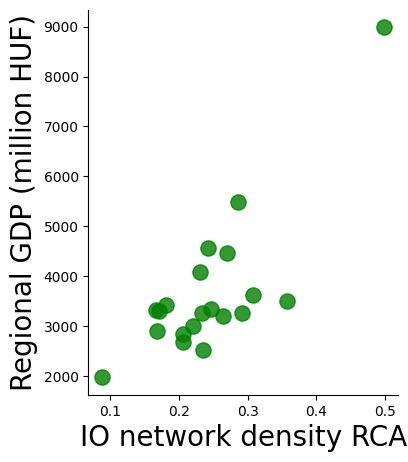

In [179]:
# correlation with GDP
rnet_table = pd.read_csv("../outputs/region_network_descriptive.csv", sep=";")
gdp_df = pd.read_csv("../data/nuts3_gdp.csv", sep=";",)
#gdp_df["gdp_growth"] = gdp_df["2019"] / gdp_df["2010"]

def gdp_density_plot(network_df, gdp_df, density_type, gdp_year, xlabel_text, colorcode, ax=None):
    network_df = pd.merge(
        network_df,
        gdp_df[["region_name", gdp_year]].rename(columns={gdp_year:"gdp"}),
        left_on="megye_nev",
        right_on="region_name",
        how="left"
    )
    if ax is None:
        ax = plt.gca()
    ax.scatter(network_df[density_type], network_df["gdp"], s=120, color=colorcode, alpha=0.8)
    #ax.semilogy()
    ax.set_xlabel(xlabel_text, size=20)
    ax.set_ylabel("Regional GDP (million HUF)", size=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.text(.1, 9000, round(network_df[density_type].corr(network_df["gdp"]),3), ha='left', va='top')

fig, ax = plt.subplots(1,1, figsize=(4,5))
gdp_density_plot(rnet_table, gdp_df, density_type="io_density_rca", gdp_year="2018", xlabel_text="IO network density RCA", colorcode="Green")

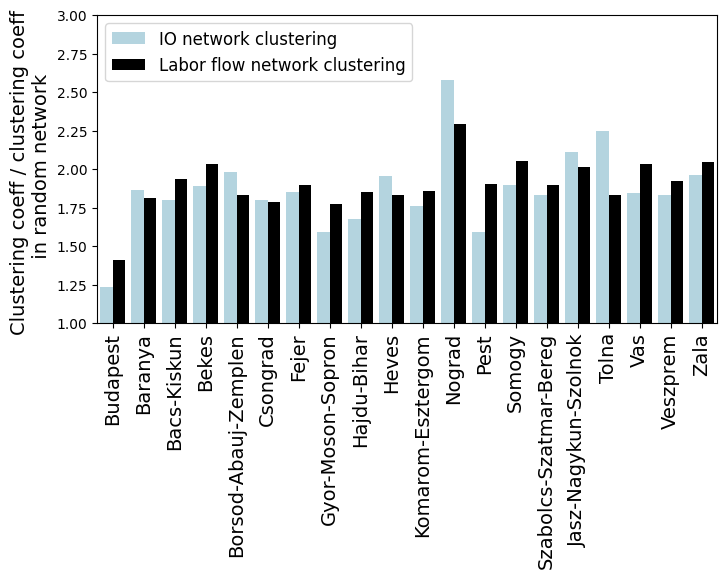

In [36]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "io_clustering_random", "lab_clustering_random"]].set_index("megye_nev").stack().reset_index()
#gbar_data = rnet_table[["megye_nev", "io_clustering", "lab_clustering"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "clustering_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Lightblue", "Black"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="clustering_type", palette = colors, ax=ax)
ax.set_ylim(1, 3)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("Clustering coeff / clustering coeff \n in random network", size=14)

legend_labels = ["IO network clustering", "Labor flow network clustering"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=12)
plt.show()

In [ ]:
# grouped barplot
gbar_data = rnet_table[["megye_nev", "io_clustering_random_rca", "lab_clustering_random_rca"]].set_index("megye_nev").stack().reset_index()
gbar_data.columns = ["megye_nev", "density_type", "value"]
region_names = rnet_table["megye_nev"].tolist()
colors = ["Grey", "Darkgreen"]

fig, ax = plt.subplots(1,1, figsize=(8,4))
sns.barplot(data=gbar_data, x="megye_nev", y="value", hue="density_type", palette = colors, ax=ax)
ax.set_ylim(0, 0.55)
ax.set_xticklabels(region_names, rotation=90, size=14)
ax.set_xlabel("")
ax.set_ylabel("IO network density", size=14)

legend_labels = ["All industries", "Industries with RCA"]
h, l = ax.get_legend_handles_labels()
ax.legend(h, legend_labels, title="", fontsize=14)
plt.show()

In [7]:
rnet_table.columns

Index(['reg', 'io_nodes', 'io_edges', 'io_density', 'io_clustering',
       'io_clustering_random', 'io_nodes_rca', 'io_edges_rca',
       'io_density_rca', 'io_clustering_rca', 'io_clustering_random_rca',
       'lab_nodes', 'lab_edges', 'lab_density', 'lab_clustering',
       'lab_clustering_random', 'lab_nodes_rca', 'lab_edges_rca',
       'lab_density_rca', 'lab_clustering_rca', 'lab_clustering_random_rca',
       'io_rca_per_all', 'megye_nev'],
      dtype='object')